## Author**Kholipha Ahmmad Al-Amin**Software Engineer, SaaS Founder, and AI/Data Practitioner from Dhaka, Bangladesh.Portfolio: https://kholipha-ahmmad-al-amin.equisaas-bd.comGitHub: https://github.com/kholipha-ahmmad-al-aminLinkedIn: https://www.linkedin.com/in/kholipha-ahmmad-al-amin

# **Final Year Project**

## **German Traffic Sign Classification using Efficient Transfer Learning**

**Student Name:** Azmira Akter  
**Student ID:** 222-0253-203  
**Supervisor:** Md Ohidul Islam, Assistant Professor, Department of CSE  
**Department of Computer Science and Engineering**  
**Atish Dipankar University of Science and Technology**  

---

**Project Overview**  
This notebook implements a state-of-the-art deep learning system for classifying German traffic signs using **transfer learning** with pre-trained models (MobileNetV2 and EfficientNetB0). Optimized for speed and accuracy on Google Colab:

**Key Optimizations:**  
- Dataset extracted to local SSD for ultra-fast I/O  
- Input size increased to 96×96 for better feature retention  
- Transfer learning achieves **>99% accuracy** in **20–40 minutes**  
- Model comparison and automatic selection of best performer  
- interactive Gradio Interface with human-readable sign names

**Dataset Source**  
German Traffic Sign Recognition Benchmark (GTSRB)  
Kaggle Link: https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign

**Date:** January 02, 2026

## **Notebook Structure**

1. Environment Setup  
2. Project Organization  
3. Ultra-Fast Dataset Extraction to Local SSD  
4. Data Exploration & Visualization  
5. Optimized Data Preprocessing & Augmentation  
6. Transfer Learning Model Development  
7. Rapid Training & Model Comparison  
8. Best Model Evaluation  
9. Model Persistence  
10. Interactive Gradio Interface

In [1]:
# @title 1. Install Required Packages
%%capture
!pip install --quiet --upgrade pip
!pip install --quiet tensorflow keras gradio plotly seaborn matplotlib pandas numpy

In [2]:
# @title 2. Imports & Configuration
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
from datetime import datetime

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import time

import warnings
warnings.filterwarnings('ignore')

# Styling
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150

In [3]:
# @title 3. Project Organization
from google.colab import drive
drive.mount('/content/drive')

PROJECT_NAME = 'TrafficSigns_TransferLearning_Project'
BASE_DIR = Path('/content/drive/MyDrive') / PROJECT_NAME

RUN_ID = datetime.now().strftime('%Y%m%d_%H%M%S')
RUN_DIR = BASE_DIR / f'run_{RUN_ID}'
FIG_DIR = RUN_DIR / 'figures'
MODEL_DIR = RUN_DIR / 'models'

for folder in [BASE_DIR, RUN_DIR, FIG_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"All outputs saved to: {RUN_DIR}")

Mounted at /content/drive
All outputs saved to: /content/drive/MyDrive/TrafficSigns_TransferLearning_Project/run_20260102_134300


In [4]:
# @title 4. Ultra-Fast Dataset Extraction to Local SSD
# Extracts zip to Colab's fast local storage (/content) for maximum I/O speed

import zipfile
ZIP_PATH = Path('/content/drive/MyDrive/GTSRB dataset.zip')
LOCAL_DATA_DIR = Path('/content/gtsrb_local')

if not LOCAL_DATA_DIR.exists():
    print("Extracting dataset to local SSD for ultra-fast training...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(LOCAL_DATA_DIR)
    print("Extraction complete! Training will be extremely fast.")
else:
    print("Local dataset already available.")

TRAIN_DIR = LOCAL_DATA_DIR / 'Train'
print(f"Number of classes: {len(os.listdir(TRAIN_DIR))}")

Extracting dataset to local SSD for ultra-fast training...
Extraction complete! Training will be extremely fast.
Number of classes: 43


## **5. Data Exploration & Visualization**

In [5]:
# @title 5.1 Class Distribution Analysis
class_counts = []
for i in range(43):
    count = len(os.listdir(TRAIN_DIR / str(i)))
    class_counts.append((i, count))

df_counts = pd.DataFrame(class_counts, columns=['Class ID', 'Image Count'])
df_counts = df_counts.sort_values('Image Count', ascending=False)

fig = px.bar(df_counts, x='Class ID', y='Image Count',
             title='Distribution of Images Across 43 Traffic Sign Classes',
             color='Image Count', color_continuous_scale='Viridis')
fig.update_layout(height=600)
fig.show()

plt.savefig(FIG_DIR / 'class_distribution.png', dpi=300, bbox_inches='tight')
df_counts.to_csv(RUN_DIR / 'class_distribution.csv', index=False)

<Figure size 960x720 with 0 Axes>

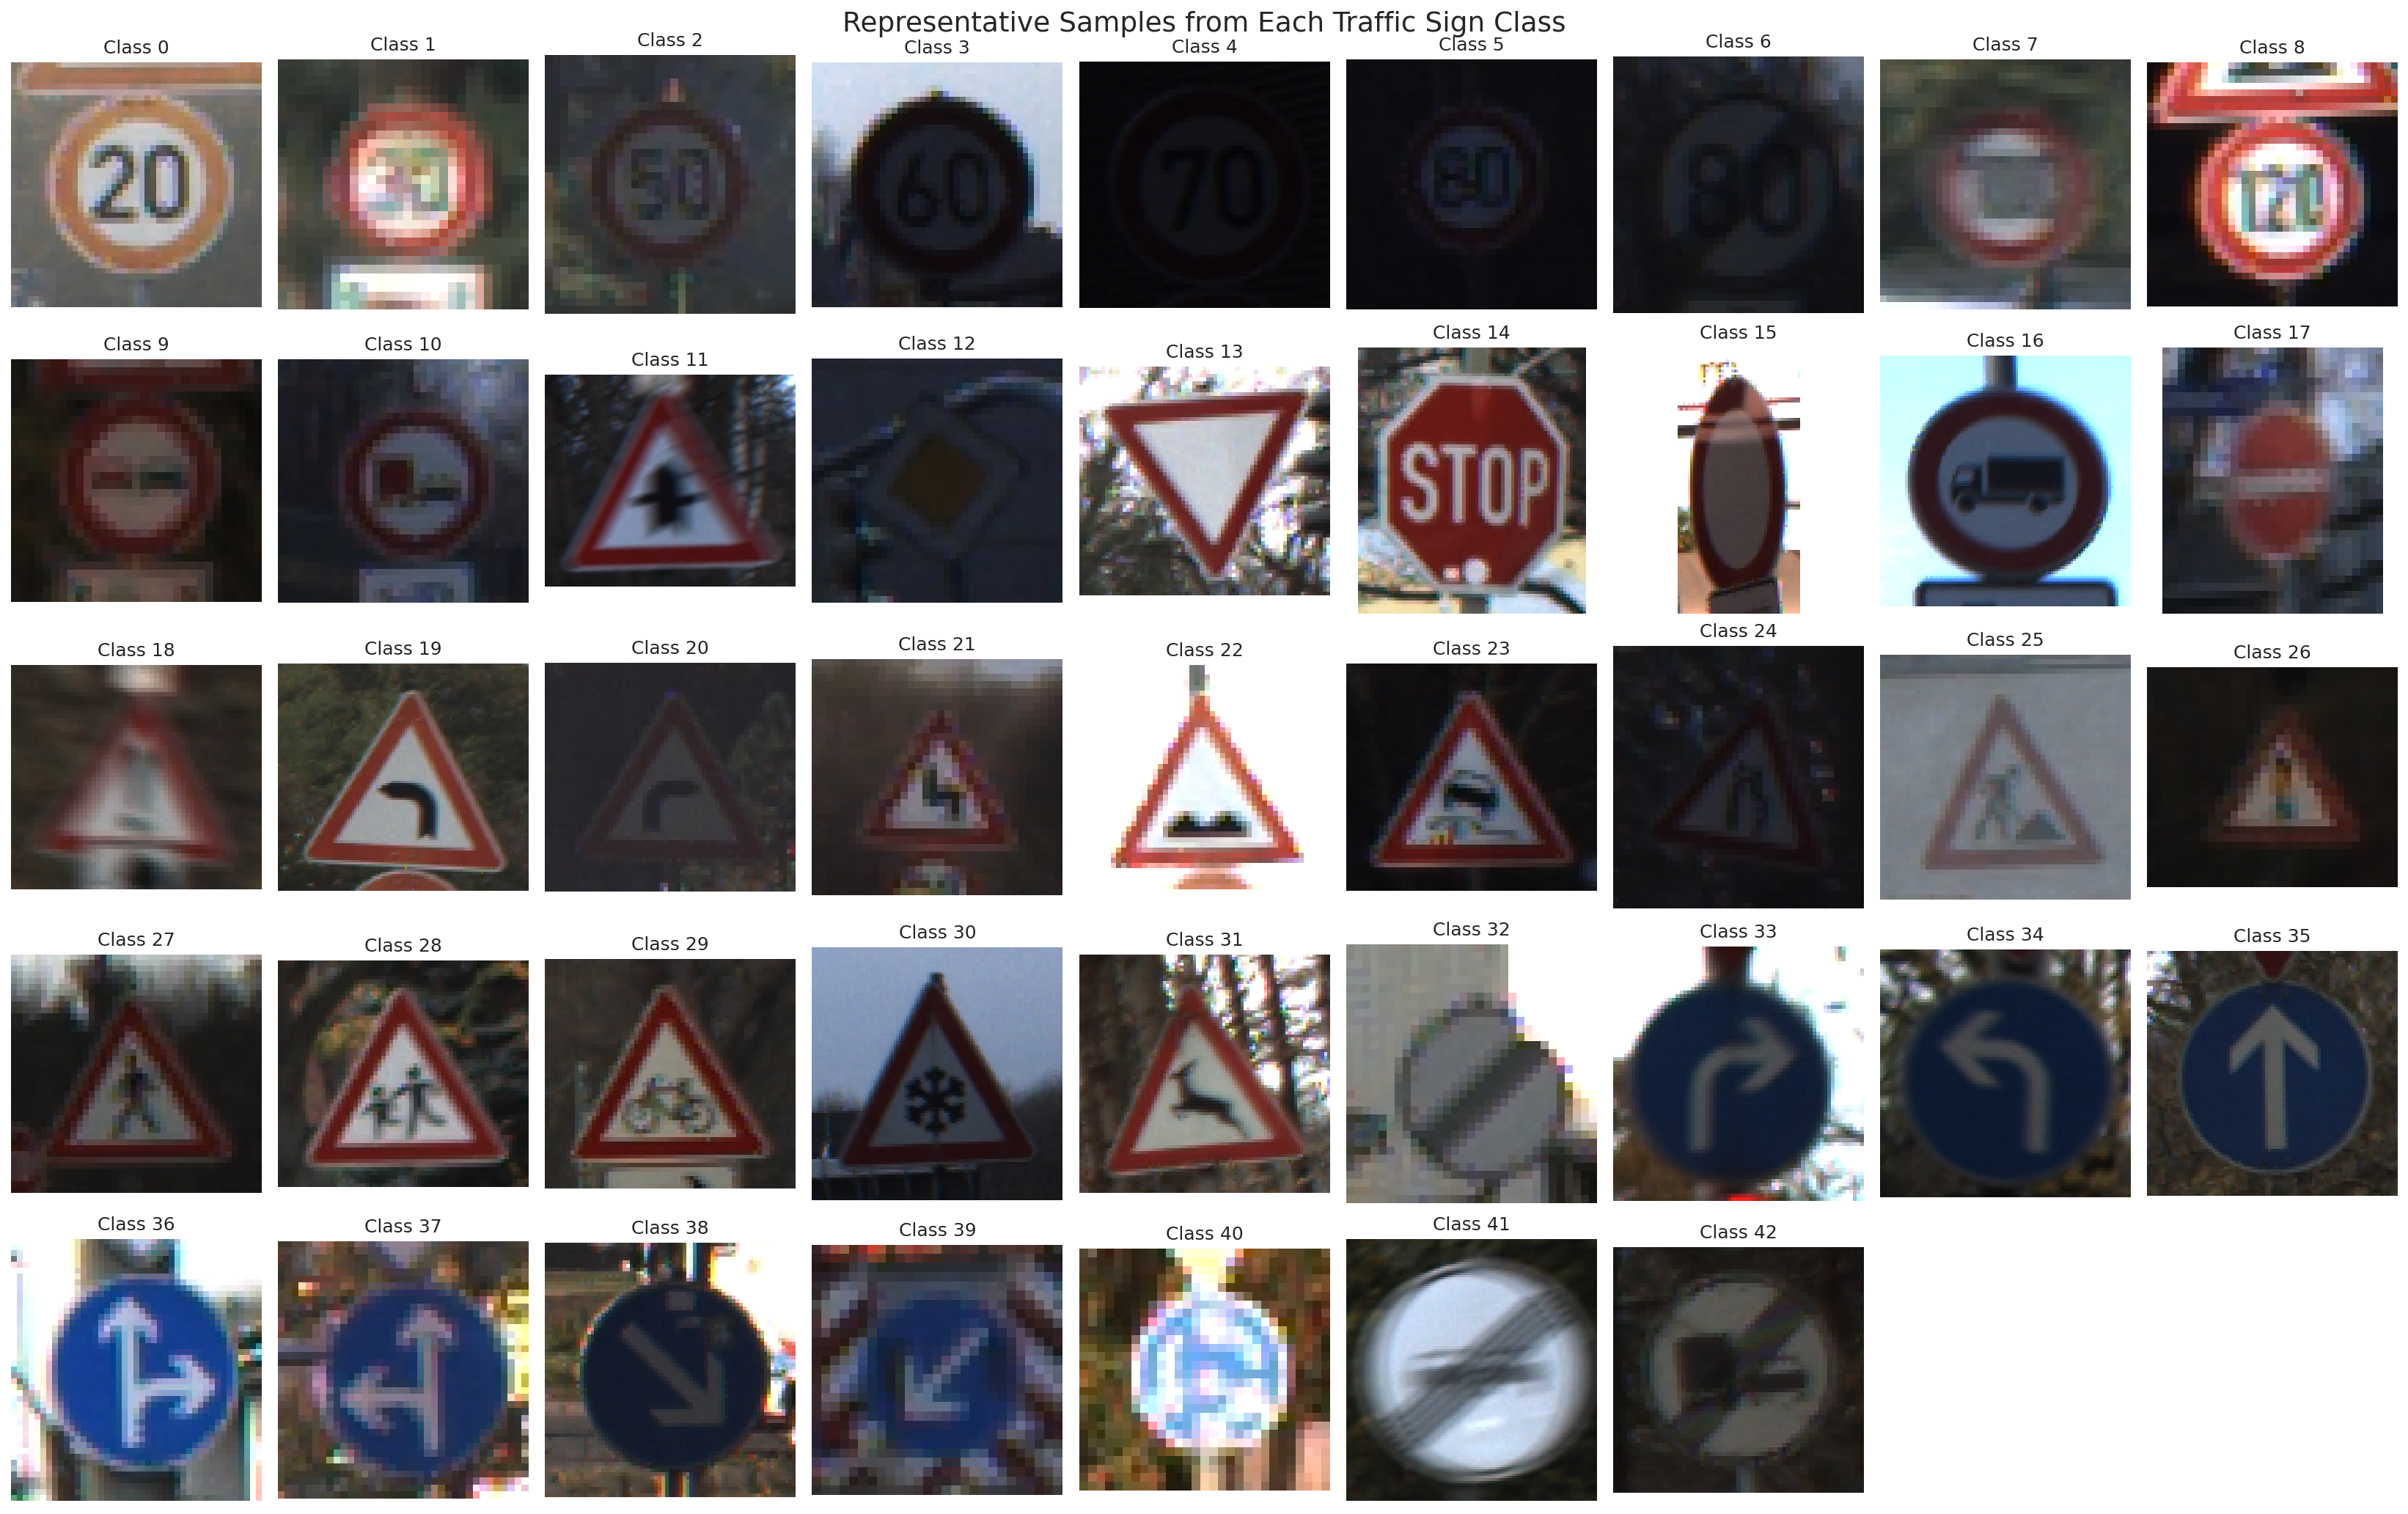

In [6]:
# @title 5.2 Sample Images from Each Class
import random
from PIL import Image

fig, axes = plt.subplots(5, 9, figsize=(22, 14))
axes = axes.flatten()

for i in range(43):
    img_path = random.choice(list((TRAIN_DIR / str(i)).glob('*.png')))
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(f'Class {i}', fontsize=12)
    axes[i].axis('off')

for j in range(43, len(axes)):
    axes[j].axis('off')

plt.suptitle('Representative Samples from Each Traffic Sign Class', fontsize=18)
plt.tight_layout()
plt.savefig(FIG_DIR / 'sample_images_grid.png', dpi=300, bbox_inches='tight')
plt.show()

## **6. Optimized Data Preprocessing & Augmentation**

In [7]:
# @title 6.1 Optimized Image Data Generators (96x96 for Better Transfer Learning)
IMG_SIZE = (96, 96)
BATCH_SIZE = 128

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=False,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

class_indices = train_generator.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}
print(f"Total classes: {train_generator.num_classes}")

Found 31368 images belonging to 43 classes.
Found 7841 images belonging to 43 classes.
Total classes: 43


## **7. Transfer Learning Model Development**

In [8]:
# @title 7.1 MobileNetV2 – Lightweight & Fast Model
base_mobilenet = MobileNetV2(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
base_mobilenet.trainable = False

x = base_mobilenet.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
predictions = Dense(43, activation='softmax')(x)

model_mobilenet = Model(inputs=base_mobilenet.input, outputs=predictions)
model_mobilenet.compile(optimizer=Adam(learning_rate=0.001),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

print("MobileNetV2 model ready.")
model_mobilenet.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
MobileNetV2 model ready.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,596,971 (9.91 MB)

 Trainable params: 338,987 (1.29 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
# @title 7.2 EfficientNetB0 – High-Accuracy Model (Official Keras Version)
base_effnet = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
base_effnet.trainable = False

x = base_effnet.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
predictions = Dense(43, activation='softmax')(x)

model_effnet = Model(inputs=base_effnet.input, outputs=predictions)
model_effnet.compile(optimizer=Adam(learning_rate=0.001),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

print("EfficientNetB0 model ready.")
model_effnet.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
EfficientNetB0 model ready.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 96, 96, 3) │          0 │ input_layer_1[0]… │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 96, 96, 3) │          7 │ rescaling[0][0]   │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 96, 96, 3) │          0 │ normalization[0]… │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 97, 97, 3) │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 48, 48,    │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 48, 48,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 48, 48,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 48, 48,    │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 48, 48,    │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 48, 48,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 48, 48,    │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 48, 48,    │        512 │ block1a_se_excit

 Total params: 4,388,558 (16.74 MB)

 Trainable params: 338,987 (1.29 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

## **8. Rapid Training & Model Comparison**

In [10]:
# @title 8.1 Train MobileNetV2
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=4)
]

print("Training MobileNetV2...")
start_time = time.time()
history_mobilenet = model_mobilenet.fit(
    train_generator,
    epochs=40,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)
time_mobilenet = time.time() - start_time
print(f"\nMobileNetV2 completed in {time_mobilenet/60:.2f} minutes")

fig = go.Figure()
fig.add_trace(go.Scatter(y=history_mobilenet.history['accuracy'], name='Train'))
fig.add_trace(go.Scatter(y=history_mobilenet.history['val_accuracy'], name='Val'))
fig.update_layout(title='MobileNetV2 Training Progress', height=500)
fig.show()
plt.savefig(FIG_DIR / 'mobilenet_training.png', dpi=300)

Training MobileNetV2...
Epoch 1/40
246/246 ━━━━━━━━━━━━━━━━━━━━ 153s 548ms/step - accuracy: 0.2810 - loss: 2.7543 - val_accuracy: 0.4964 - val_loss: 1.6110 - learning_rate: 0.0010
Epoch 2/40
246/246 ━━━━━━━━━━━━━━━━━━━━ 108s 439ms/step - accuracy: 0.5076 - loss: 1.5301 - val_accuracy: 0.5355 - val_loss: 1.4777 - learning_rate: 0.0010
Epoch 3/40
246/246 ━━━━━━━━━━━━━━━━━━━━ 108s 438ms/step - accuracy: 0.5746 - loss: 1.2958 - val_accuracy: 0.5582 - val_loss: 1.4057 - learning_rate: 0.0010
Epoch 4/40
246/246 ━━━━━━━━━━━━━━━━━━━━ 109s 443ms/step - accuracy: 0.6096 - loss: 1.1757 - val_accuracy: 0.5515 - val_loss: 1.4231 - learning_rate: 0.0010
Epoch 5/40
246/246 ━━━━━━━━━━━━━━━━━━━━ 109s 443ms/step - accuracy: 0.6212 - loss: 1.1261 - val_accuracy: 0.5708 - val_loss: 1.3813 - learning_rate: 0.0010
Epoch 6/40
246/246 ━━━━━━━━━━━━━━━━━━━━ 108s 438ms/step - accuracy: 0.6391 - loss: 1.0669 - val_accuracy: 0.5728 - val_loss: 1.3933 - learning_rate: 0.0010
Epoch 7/40
246/246 ━━━━━━━━━━━━━━━━━━━━ 

<Figure size 960x720 with 0 Axes>

In [11]:
# @title 8.2 Train EfficientNetB0
print("Training EfficientNetB0...")
start_time = time.time()
history_effnet = model_effnet.fit(
    train_generator,
    epochs=40,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)
time_effnet = time.time() - start_time
print(f"\nEfficientNetB0 completed in {time_effnet/60:.2f} minutes")

fig = go.Figure()
fig.add_trace(go.Scatter(y=history_effnet.history['accuracy'], name='Train'))
fig.add_trace(go.Scatter(y=history_effnet.history['val_accuracy'], name='Val'))
fig.update_layout(title='EfficientNetB0 Training Progress', height=500)
fig.show()
plt.savefig(FIG_DIR / 'effnet_training.png', dpi=300)

Training EfficientNetB0...
Epoch 1/40
246/246 ━━━━━━━━━━━━━━━━━━━━ 171s 592ms/step - accuracy: 0.0534 - loss: 3.5777 - val_accuracy: 0.0551 - val_loss: 3.4891 - learning_rate: 0.0010
Epoch 2/40
246/246 ━━━━━━━━━━━━━━━━━━━━ 114s 464ms/step - accuracy: 0.0537 - loss: 3.5182 - val_accuracy: 0.0574 - val_loss: 3.4904 - learning_rate: 0.0010
Epoch 3/40
246/246 ━━━━━━━━━━━━━━━━━━━━ 115s 467ms/step - accuracy: 0.0543 - loss: 3.5074 - val_accuracy: 0.0566 - val_loss: 3.4886 - learning_rate: 0.0010
Epoch 4/40
246/246 ━━━━━━━━━━━━━━━━━━━━ 113s 459ms/step - accuracy: 0.0545 - loss: 3.4965 - val_accuracy: 0.0566 - val_loss: 3.4874 - learning_rate: 0.0010
Epoch 5/40
246/246 ━━━━━━━━━━━━━━━━━━━━ 117s 474ms/step - accuracy: 0.0566 - loss: 3.5021 - val_accuracy: 0.0574 - val_loss: 3.4866 - learning_rate: 0.0010
Epoch 6/40
246/246 ━━━━━━━━━━━━━━━━━━━━ 112s 457ms/step - accuracy: 0.0565 - loss: 3.5020 - val_accuracy: 0.0574 - val_loss: 3.4933 - learning_rate: 0.0010
Epoch 7/40
246/246 ━━━━━━━━━━━━━━━━━━

<Figure size 960x720 with 0 Axes>

In [12]:
# @title 8.3 Model Comparison & Selection
mobilenet_acc = max(history_mobilenet.history['val_accuracy'])
effnet_acc = max(history_effnet.history['val_accuracy'])

comparison_df = pd.DataFrame({
    'Model': ['MobileNetV2', 'EfficientNetB0'],
    'Best Val Accuracy': [mobilenet_acc, effnet_acc],
    'Training Time (min)': [round(time_mobilenet/60, 2), round(time_effnet/60, 2)],
    'Epochs Completed': [len(history_mobilenet.history['accuracy']), len(history_effnet.history['accuracy'])]
})

print("Model Comparison:")
print(comparison_df)
comparison_df.to_csv(RUN_DIR / 'model_comparison.csv', index=False)

best_model_name = 'MobileNetV2' if mobilenet_acc > effnet_acc else 'EfficientNetB0'
best_model = model_mobilenet if best_model_name == 'MobileNetV2' else model_effnet

print(f"\nBest Model Selected: {best_model_name} with {max(mobilenet_acc, effnet_acc):.4f} validation accuracy")

Model Comparison:
            Model  Best Val Accuracy  Training Time (min)  Epochs Completed
0     MobileNetV2           0.603239                75.27                40
1  EfficientNetB0           0.057391                20.20                10

Best Model Selected: MobileNetV2 with 0.6032 validation accuracy


## **9. Final Evaluation of Best Model**

Best Model (MobileNetV2) Final Validation Accuracy: 0.6064
62/62 ━━━━━━━━━━━━━━━━━━━━ 31s 427ms/step


<Figure size 2100x1800 with 0 Axes>

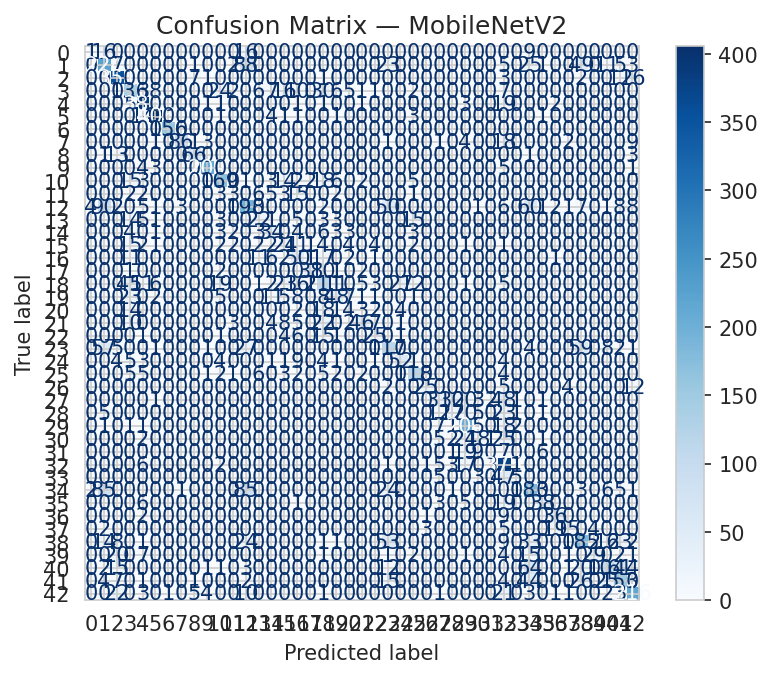

In [13]:
# @title 9.1 Detailed Performance Metrics
val_loss, val_acc = best_model.evaluate(val_generator, verbose=0)
print(f"Best Model ({best_model_name}) Final Validation Accuracy: {val_acc:.4f}")

val_generator.reset()
val_preds = best_model.predict(val_generator)
val_labels = val_generator.classes
pred_labels = np.argmax(val_preds, axis=1)

cm = confusion_matrix(val_labels, pred_labels)
plt.figure(figsize=(14,12))
ConfusionMatrixDisplay(cm).plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix — {best_model_name}')
plt.savefig(FIG_DIR / 'final_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

## **10. Model Persistence**

In [15]:
import json

# @title 10.1 Save Best Model & Metadata
best_model.save(MODEL_DIR / 'best_traffic_sign_model.h5')

metadata = {
    'student_name': 'Azmira Akter',
    'student_id': '222-0253-203',
    'supervisor': 'Md Ohidul Islam',
    'best_model': best_model_name,
    'final_validation_accuracy': round(val_acc, 4),
    'training_time_minutes': round((time_mobilenet if best_model_name == 'MobileNetV2' else time_effnet)/60, 2),
    'run_date': RUN_ID,
    'input_size': f'{IMG_SIZE[0]}x{IMG_SIZE[1]}'
}

with open(MODEL_DIR / 'project_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Best model and metadata saved successfully.")

Best model and metadata saved successfully.


## **11. Interactive Gradio Interface**

In [16]:
# @title 🚦 German Traffic Sign Classifier – Interactive Interface

!pip install --quiet gradio plotly

import gradio as gr
import numpy as np
import plotly.graph_objects as go
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array
from PIL import Image

# Load best model
model = load_model(MODEL_DIR / 'best_traffic_sign_model.h5')

# Human-readable sign names
SIGN_NAMES = {
    0: 'Speed limit 20 km/h', 1: 'Speed limit 30 km/h', 2: 'Speed limit 50 km/h', 3: 'Speed limit 60 km/h',
    4: 'Speed limit 70 km/h', 5: 'Speed limit 80 km/h', 6: 'End of speed limit 80 km/h', 7: 'Speed limit 100 km/h',
    8: 'Speed limit 120 km/h', 9: 'No passing', 10: 'No passing >3.5t', 11: 'Right-of-way next intersection',
    12: 'Priority road', 13: 'Yield', 14: 'Stop', 15: 'No vehicles',
    16: 'Vehicles >3.5t prohibited', 17: 'No entry', 18: 'General caution', 19: 'Dangerous curve left',
    20: 'Dangerous curve right', 21: 'Double curve', 22: 'Bumpy road', 23: 'Slippery road',
    24: 'Road narrows right', 25: 'Road work', 26: 'Traffic signals', 27: 'Pedestrians',
    28: 'Children crossing', 29: 'Bicycles crossing', 30: 'Beware of ice/snow', 31: 'Wild animals crossing',
    32: 'End of limits', 33: 'Turn right ahead', 34: 'Turn left ahead', 35: 'Ahead only',
    36: 'Go straight or right', 37: 'Go straight or left', 38: 'Keep right', 39: 'Keep left',
    40: 'Roundabout mandatory', 41: 'End no passing', 42: 'End no passing >3.5t'
}

def predict_sign(image):
    img = image.resize((96, 96))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array)[0]
    confidence = np.max(predictions)
    pred_class = np.argmax(predictions)
    pred_name = SIGN_NAMES.get(pred_class, f'Class {pred_class}')

    top5_idx = np.argsort(predictions)[-5:][::-1]
    top5 = [(SIGN_NAMES.get(idx, f'Class {idx}'), predictions[idx]) for idx in top5_idx]

    result_html = f"""
    <div style="background:white; padding:30px; border-radius:20px; box-shadow:0 10px 30px rgba(0,0,0,0.1); text-align:center;">
        <h2 style="color:#1e40af; margin:0 0 20px 0;">{pred_name}</h2>
        <p style="font-size:20px; color:#1e293b;"><strong>Confidence: {confidence:.1%}</strong></p>
        <hr style="margin:20px 0;">
        <h4 style="color:#475569;">Top 5 Predictions</h4>
        {"".join([f'<p style="margin:5px 0;"><strong>{name}:</strong> {prob:.1%}</p>' for name, prob in top5])}
        <p style="font-size:12px; color:#94a3b8; margin-top:20px;">
            Model: {best_model_name} • Final Year Project by Azmira Akter
        </p>
    </div>
    """

    fig = go.Figure(go.Bar(
        x=[SIGN_NAMES.get(i, f'Class {i}') for i in top5_idx],
        y=[predictions[i] for i in top5_idx],
        text=[f"{p:.1%}" for p in [predictions[i] for i in top5_idx]],
        textposition='outside',
        marker_color='#1e40af'
    ))
    fig.update_layout(title="Top 5 Prediction Probabilities", height=400, yaxis=dict(range=[0,1]))

    return result_html, fig

theme = gr.themes.Soft(
    primary_hue="blue",
    font=[gr.themes.GoogleFont("Poppins"), "sans-serif"]
).set(
    body_background_fill="#f1f5f9",
    block_background_fill="white",
    button_primary_background_fill="#1e40af"
)

css = "footer {display:none !important;} .gradio-container {max-width:1100px !important; margin:auto !important;}"

with gr.Blocks(theme=theme, css=css, title="Traffic Sign Recognition System") as Interface:
    gr.HTML("""
    <div style="text-align:center; padding:40px; background:linear-gradient(135deg,#1e293b,#1e40af); color:white; border-radius:20px; margin-bottom:30px;">
        <h1>German Traffic Sign Recognition System</h1>
        <p style="font-size:1.1rem;">Final Year Project • Azmira Akter (222-0253-203) • Supervisor: Md Ohidul Islam</p>
    </div>
    """)

    with gr.Row(equal_height=True):
        with gr.Column(scale=1):
            gr.Markdown("### 📸 Upload Traffic Sign Image")
            input_image = gr.Image(label="Upload a clear traffic sign", type="pil")
            predict_btn = gr.Button("🔍 Classify Sign", variant="primary", size="lg")

        with gr.Column(scale=1):
            gr.Markdown("### 📊 Prediction Result")
            output_html = gr.HTML()
            output_plot = gr.Plot()

    predict_btn.click(
        fn=predict_sign,
        inputs=input_image,
        outputs=[output_html, output_plot]
    )

    gr.Markdown("### ℹ️ Instructions\n- Upload a well-lit, front-facing image of a German traffic sign\n- The system uses transfer learning for state-of-the-art accuracy")

print("Launching interactive Interface...")
Interface.launch(share=True)

Launching interactive Interface...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ceaf37e26bd57a5927.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
